In [4]:
import xarray as xr
import yaml
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import sys
import os
import numpy as np
sys.path.append(os.path.dirname('../workflow'))
import intake
from workflow.scripts.plotting_tools import create_facet_plot,get_model_colordict, global_map
from workflow.scripts.utils import convert_lon_to_180, model_levels_to_pressure_levels, global_avg

In [5]:
cat = intake.open_esm_datastore("../catalogues/merge_CMIP6.json")



In [6]:
catctrl = cat.search(
    experiment_id=['piClim-control'],
    table_id='Amon',
    variable_id='hur',
    source_id=['NorESM2-LM','GISS-E2-1-G','MPI-ESM-1-2-HAM',
                'MIROC6','CNRM-ESM2-1', 'UKESM1-0-LL', 'IPSL-CM6A-LR-INCA','EC-Earth3-AerChem',
                'GFDL-ESM4']
)

cat_exp = cat.search(
    experiment_id=['piClim-2xdust'],
    table_id='Amon',
    variable_id='hur',
    source_id=['NorESM2-LM','GISS-E2-1-G','MPI-ESM-1-2-HAM',
                'MIROC6','CNRM-ESM2-1', 'UKESM1-0-LL', 'IPSL-CM6A-LR-INCA','EC-Earth3-AerChem',
                'GFDL-ESM4']
)

In [13]:
datadict_keys=['RFMIP.CNRM-CERFACS.piClim-control.r1i1p1f2',
 'RFMIP.IPSL.piClim-control.r1i1p1f1',
 'AerChemMIP.MOHC.piClim-control.r1i1p1f4',
 'RFMIP.NCC.piClim-control.r1i1p2f1',
 'RFMIP.MIROC.piClim-control.r11i1p1f1',
 'RFMIP.NASA-GISS.piClim-control.r1i1p3f1',
 'RFMIP.HAMMOZ-Consortium.piClim-control.r1i1p1f1',
 'RFMIP.EC-Earth-Consortium.piClim-control.r1i1p1f1',
 'AerChemMIP.NOAA-GFDL.piClim-control.r1i1p1f1'
]


In [8]:
ctrldict = catctrl.to_dataset_dict()


--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.experiment_id.member_id'


In [14]:
ctrldict = {k:ctrldict[k] for k in datadict_keys}

In [17]:
expdict = cat_exp.to_dataset_dict()


--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.experiment_id.member_id'


In [21]:
ctrldict['RFMIP.NCC.piClim-control.r1i1p2f1'].plev

<xarray.DataArray 'plev' (plev: 19)> Size: 152B
array([100000.,  92500.,  85000.,  70000.,  60000.,  50000.,  40000.,  30000.,
        25000.,  20000.,  15000.,  10000.,   7000.,   5000.,   3000.,   2000.,
         1000.,    500.,    100.])
Coordinates:
  * plev     (plev) float64 152B 1e+05 9.25e+04 8.5e+04 ... 1e+03 500.0 100.0
Attributes:
    units:          Pa
    axis:           Z
    positive:       down
    long_name:      pressure
    standard_name:  air_pressure

In [22]:
ctrldict['RFMIP.NCC.piClim-control.r1i1p2f1']

<xarray.Dataset> Size: 1GB
Dimensions:    (member_id: 1, time: 1080, plev: 19, lat: 96, lon: 144, bnds: 2)
Coordinates:
  * time       (time) object 9kB 0001-01-16 12:00:00 ... 0090-12-16 12:00:00
    time_bnds  (time, bnds) object 17kB dask.array<chunksize=(1, 2), meta=np.ndarray>
  * plev       (plev) float64 152B 1e+05 9.25e+04 8.5e+04 ... 1e+03 500.0 100.0
  * lat        (lat) float64 768B -90.0 -88.11 -86.21 ... 86.21 88.11 90.0
    lat_bnds   (lat, bnds) float64 2kB dask.array<chunksize=(96, 2), meta=np.ndarray>
  * lon        (lon) float64 1kB 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
    lon_bnds   (lon, bnds) float64 2kB dask.array<chunksize=(144, 2), meta=np.ndarray>
  * member_id  (member_id) object 8B 'r1i1p2f1'
Dimensions without coordinates: bnds
Data variables:
    hur        (member_id, time, plev, lat, lon) float32 1GB dask.array<chunksize=(1, 1, 19, 96, 144), meta=np.ndarray>
Attributes: (12/58)
    Conventions:                      CF-1.7 CMIP-6.2
    activity_id:                      RFMIP AerChemMIP
    branch_method:                    Hybrid-restart from year 1751-01-01 of ...
    branch_time:                      0.0
    branch_time_in_child:             0.0
    branch_time_in_parent:            485450.0
    ...                               ...
    intake_esm_attrs:grid_label:      gn
    intake_esm_attrs:activity_id:     RFMIP
    intake_esm_attrs:institution_id:  NCC
    intake_esm_attrs:version:         20210811
    intake_esm_attrs:_data_format_:   netcdf
    intake_esm_dataset_key:           RFMIP.NCC.piClim-control.r1i1p2f1

In [25]:

noresm_exp = expdict['AerChemMIP.NCC.piClim-2xdust.r1i1p2f1']
noresm_ctrl = ctrldict]}
noresm_rhdiff = expdict['AerChemMIP.NCC.piClim-2xdust.r1i1p2f1']['hur'].sel(plev=60000).isel(member_id=0)  - ctrldict['RFMIP.NCC.piClim-control.r1i1p2f1']['hur'].sel(plev=60000).isel(member_id=0) 

In [27]:
noresm_rhdiff = noresm_rhdiff.resample(time='YE').mean()

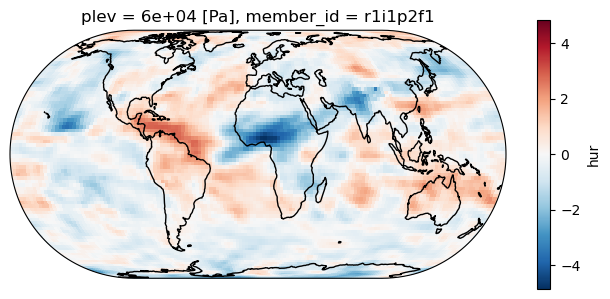

In [43]:
fig,ax = plt.subplots(subplot_kw={'projection':ccrs.EckertIV()}, figsize=(8,3.5))
noresm_rhdiff.isel(time=slice(3,None)).mean(dim='time').plot(ax=ax,transform=ccrs.PlateCarree())
ax.coastlines()